In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importar los data sets

## Hogares

In [232]:
#Importamos el data set
test_hogares = pd.read_csv("test_hogares.csv")
test_hogares.head()
test_vars_h = test_hogares.columns
test_hogares

,id,Clase,Dominio,P5000,P5010,P5090,P5100,P5130,P5140,Nper,Npersug,Li,Lp,Fex_c,Depto,Fex_dpto
0,2a7ddc2779480d7f19834953,1,SANTA MARTA,4,3,1,NaN,400000.0,NaN,5,5,121449.452925,275594.029448,7.826095,47,7.528079
1,a0c2e751e582fd49d564f308,1,SANTA MARTA,4,3,4,NaN,500000.0,NaN,6,6,121449.452925,275594.029448,15.002708,47,15.327736
2,57273d19e8464a5ff66a582b,2,RURAL,3,1,1,NaN,250000.0,NaN,2,2,100763.337626,170886.447382,45.701877,17,50.394748
3,418d052ff7878940ab938601,1,MEDELLIN,4,3,1,NaN,600000.0,NaN,5,5,122251.781628,294093.665341,70.318877,5,80.725068
4,212a37fc17016a3c78f76852,1,MEDELLIN,5,2,2,1800000.0,2000000.0,NaN,2,2,123664.359813,293293.411227,91.241328,5,95.116936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66163,e7d3c7cc62acd33867b7b7ee,1,BARRANQUILLA,3,2,3,NaN,NaN,450000.0,4,4,127610.370110,292192.080210,48.989768,8,48.415863
66164,710db9f02de9c616f846c72e,1,CARTAGENA,3,2,3,NaN,NaN,100000.0,5,5,122811.614203,288078.106437,39.488634,13,32.499700
66165,5a0d6b6fad06e4736fb6d95f,1,ARMENIA,3,2,3,NaN,NaN,250000.0,6,6,121282.133083,278659.892172,10.332009,63,9.719097
66166,569496964b70185785b57789,1,PEREIRA,2,2,4,NaN,300000.0,NaN,5,5,121522.856805,287292.899913,16.470949,66,14.496007


In [233]:
# Importamos el data set
train_hogares = pd.read_csv("train_hogares.csv")
train_hogares.head()
train_vars_h = train_hogares.columns


In [234]:
train_hogares

,id,Clase,Dominio,P5000,P5010,P5090,P5100,P5130,P5140,Nper,...,Ingpcug,Li,Lp,Pobre,Indigente,Npobres,Nindigentes,Fex_c,Depto,Fex_dpto
0,8d0193e328305a042001a35f,1,MEDELLIN,4,2,1,NaN,400000.0,NaN,5,...,5.816661e+05,122809.534158,289878.247150,0,0,0,0,127.222038,5,146.251790
1,cf7491d7f2cc9c216bd009e7,1,MEDELLIN,5,4,3,NaN,NaN,250000.0,4,...,1.612500e+05,122809.534158,289878.247150,1,0,4,0,115.866093,5,93.080952
2,d90a57f64d2a84dbacbed2a5,1,MEDELLIN,4,2,1,NaN,700000.0,NaN,3,...,2.000000e+06,122809.534158,289878.247150,0,0,0,0,100.123276,5,89.637086
3,db34e387a94a783188ab3a33,1,MEDELLIN,3,1,1,NaN,450000.0,NaN,1,...,2.450000e+06,122809.534158,289878.247150,0,0,0,0,108.829812,5,95.584376
4,97bbef785824746ecab09c6f,1,MEDELLIN,4,3,3,NaN,NaN,500000.0,5,...,2.520000e+05,122809.534158,289878.247150,1,0,5,0,110.412859,5,124.560515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164955,0d168c0d27707687fcbf9b60,1,CALI,3,2,3,NaN,NaN,460000.0,3,...,2.824977e+05,127336.653858,280234.432107,0,0,0,0,73.088259,76,77.806334
164956,757f32d9b76aaa11eb93b4a6,1,BOGOTA,3,3,3,NaN,NaN,650000.0,8,...,3.600000e+05,123416.961118,280522.423188,0,0,0,0,413.891448,11,413.891448
164957,ff4ecf438cf2375b8d511645,1,BOGOTA,5,4,1,NaN,2000000.0,NaN,10,...,6.934544e+05,123416.961118,280522.423188,0,0,0,0,233.379248,11,233.379248
164958,5f037d9ddb23a0223d937b30,1,BOGOTA,2,1,3,NaN,NaN,400000.0,4,...,4.799466e+05,123416.961118,280522.423188,0,0,0,0,386.721150,11,386.721150


In [235]:
#Vemos las intersecciones
y_train = train_hogares['Pobre']
columns_inter = test_vars_h.intersection(train_vars_h)
train_hogares = train_hogares[columns_inter]

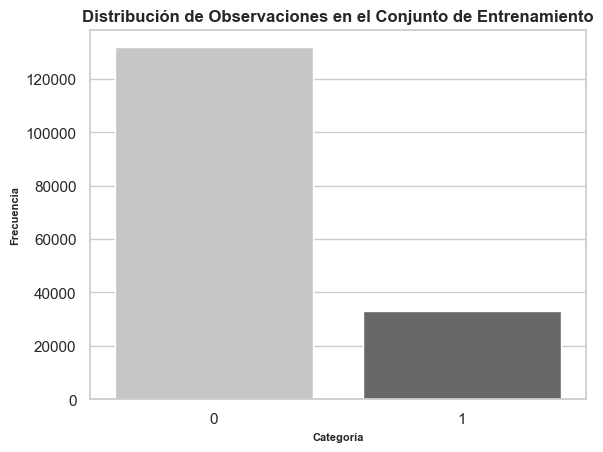

In [236]:
import seaborn as sns
#Gráfico de distribución de Pobreza
count_values = y_train.value_counts().reset_index()
count_values.columns = ['Value', 'Count']

# Crear el gráfico de barras
sns.set_theme(style='whitegrid')
sns.barplot(x='Value', y='Count', data=count_values)

# Añadir etiquetas y título
ax = sns.barplot(x='Value', y='Count', data=count_values, palette='Greys')
ax.set_xlabel('Categoría', fontsize=8, weight='bold')
ax.set_ylabel('Frecuencia', fontsize=8, weight='bold')
ax.set_title('Distribución de Observaciones en el Conjunto de Entrenamiento', fontsize=12, weight='bold')

# Mostrar el gráfico
plt.show()

In [237]:
propor = len(y_train[y_train==0])/len(y_train[y_train==1])
propor

3.99515503875969

## Personas

In [238]:
#Importar el data set
train_personas = pd.read_csv("train_personas.csv")
train_personas.head()
train_vars_p= train_personas.columns
train_personas

,id,Orden,Clase,Dominio,Estrato1,P6020,P6040,P6050,P6090,P6100,...,Iof2es,Iof3hes,Iof3ies,Iof6es,Ingtotob,Ingtotes,Ingtot,Fex_c,Depto,Fex_dpto
0,8d0193e328305a042001a35f,2,1,MEDELLIN,2,2,38,2,1.0,1.0,...,NaN,NaN,NaN,NaN,1.109190e+06,NaN,1.109190e+06,127.222038,5,146.251790
1,8d0193e328305a042001a35f,5,1,MEDELLIN,2,1,3,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
2,8d0193e328305a042001a35f,1,1,MEDELLIN,2,1,41,1,1.0,1.0,...,NaN,NaN,NaN,NaN,1.399140e+06,NaN,1.399140e+06,127.222038,5,146.251790
3,8d0193e328305a042001a35f,4,1,MEDELLIN,2,1,3,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
4,8d0193e328305a042001a35f,3,1,MEDELLIN,2,1,11,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543104,5f037d9ddb23a0223d937b30,2,1,BOGOTA,2,2,24,2,1.0,1.0,...,NaN,NaN,NaN,NaN,1.003667e+06,NaN,1.003667e+06,386.721150,11,386.721150
543105,e575d8c70d587b3be3f45a6f,1,1,BOGOTA,3,2,36,1,1.0,1.0,...,NaN,NaN,NaN,NaN,6.825000e+06,NaN,6.825000e+06,341.056945,11,341.056945
543106,e575d8c70d587b3be3f45a6f,2,1,BOGOTA,3,1,41,2,1.0,1.0,...,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000e+00,341.056945,11,341.056945
543107,e575d8c70d587b3be3f45a6f,3,1,BOGOTA,3,1,8,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,341.056945,11,341.056945


In [239]:
test_personas = pd.read_csv("test_personas.csv")
test_personas

,id,Orden,Clase,Dominio,P6020,P6040,P6050,P6090,P6100,P6210,...,P7510s5,P7510s6,P7510s7,Pet,Oc,Des,Ina,Fex_c,Depto,Fex_dpto
0,3279230a4917cdf883df34cd,1,1,MEDELLIN,1,33,1,1.0,1.0,6.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,125.720226,5,126.041802
1,3279230a4917cdf883df34cd,3,1,MEDELLIN,2,7,3,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.720226,5,126.041802
2,3279230a4917cdf883df34cd,2,1,MEDELLIN,2,37,2,1.0,1.0,6.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,125.720226,5,126.041802
3,3279230a4917cdf883df34cd,4,1,MEDELLIN,1,5,3,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.720226,5,126.041802
4,01bd1f72445acc719d19bd25,1,1,MEDELLIN,1,27,1,1.0,1.0,5.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,73.359246,5,64.143748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219639,95aca5f4d202450cdfc16c37,1,1,RIOHACHA,1,74,1,1.0,2.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219640,95aca5f4d202450cdfc16c37,2,1,RIOHACHA,2,74,2,1.0,2.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219641,95aca5f4d202450cdfc16c37,3,1,RIOHACHA,2,19,4,1.0,1.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219642,95aca5f4d202450cdfc16c37,4,1,RIOHACHA,2,18,4,1.0,1.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896


In [240]:
test_personas.columns

Index(['id', 'Orden', 'Clase', 'Dominio', 'P6020', 'P6040', 'P6050', 'P6090',
       'P6100', 'P6210', 'P6210s1', 'P6240', 'Oficio', 'P6426', 'P6430',
       'P6510', 'P6545', 'P6580', 'P6585s1', 'P6585s2', 'P6585s3', 'P6585s4',
       'P6590', 'P6600', 'P6610', 'P6620', 'P6630s1', 'P6630s2', 'P6630s3',
       'P6630s4', 'P6630s6', 'P6800', 'P6870', 'P6920', 'P7040', 'P7045',
       'P7050', 'P7090', 'P7110', 'P7120', 'P7150', 'P7160', 'P7310', 'P7350',
       'P7422', 'P7472', 'P7495', 'P7500s2', 'P7500s3', 'P7505', 'P7510s1',
       'P7510s2', 'P7510s3', 'P7510s5', 'P7510s6', 'P7510s7', 'Pet', 'Oc',
       'Des', 'Ina', 'Fex_c', 'Depto', 'Fex_dpto'],
      dtype='object')

In [241]:

# Suponiendo que test_personas es tu DataFrame y tienes las columnas mencionadas
columnas = ["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c","P6210s1"]

# Reemplazar los NaNs en cada columna por la media de esa columna
for col in columnas:
    mean_value_t = train_personas[col].mean()
    mean_value = test_personas[col].mean()  # Calcular la media de la columna, ignorando los NaN
    train_personas[col].fillna(mean_value_t, inplace=True)
    test_personas[col].fillna(mean_value, inplace=True)  # Rellenar los NaN con la media

# Mostrar el DataFrame después de la sustitución
#print(test_personas[columnas])


In [242]:
#Importar el data set
test_vars_p = test_personas.columns

In [243]:
#Vemos las intersecciones
columns_inter = test_vars_p.intersection(train_vars_p)
train_personas = train_personas[columns_inter]

In [244]:
test_personas

,id,Orden,Clase,Dominio,P6020,P6040,P6050,P6090,P6100,P6210,...,P7510s5,P7510s6,P7510s7,Pet,Oc,Des,Ina,Fex_c,Depto,Fex_dpto
0,3279230a4917cdf883df34cd,1,1,MEDELLIN,1,33,1,1.000000,1.0,6.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,125.720226,5,126.041802
1,3279230a4917cdf883df34cd,3,1,MEDELLIN,2,7,3,1.069978,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.720226,5,126.041802
2,3279230a4917cdf883df34cd,2,1,MEDELLIN,2,37,2,1.000000,1.0,6.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,125.720226,5,126.041802
3,3279230a4917cdf883df34cd,4,1,MEDELLIN,1,5,3,1.069978,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.720226,5,126.041802
4,01bd1f72445acc719d19bd25,1,1,MEDELLIN,1,27,1,1.000000,1.0,5.0,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,73.359246,5,64.143748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219639,95aca5f4d202450cdfc16c37,1,1,RIOHACHA,1,74,1,1.000000,2.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219640,95aca5f4d202450cdfc16c37,2,1,RIOHACHA,2,74,2,1.000000,2.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219641,95aca5f4d202450cdfc16c37,3,1,RIOHACHA,2,19,4,1.000000,1.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896
219642,95aca5f4d202450cdfc16c37,4,1,RIOHACHA,2,18,4,1.000000,1.0,6.0,...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,4.120660,44,5.192896


In [245]:
train_personas

,id,Orden,Clase,Dominio,P6020,P6040,P6050,P6090,P6100,P6210,...,P7510s5,P7510s6,P7510s7,Pet,Oc,Des,Ina,Fex_c,Depto,Fex_dpto
0,8d0193e328305a042001a35f,2,1,MEDELLIN,2,38,2,1.000000,1.0,3.00000,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,127.222038,5,146.251790
1,8d0193e328305a042001a35f,5,1,MEDELLIN,1,3,3,1.071237,NaN,2.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
2,8d0193e328305a042001a35f,1,1,MEDELLIN,1,41,1,1.000000,1.0,5.00000,...,2.0,1.0,2.0,1.0,1.0,NaN,NaN,127.222038,5,146.251790
3,8d0193e328305a042001a35f,4,1,MEDELLIN,1,3,3,1.071237,NaN,2.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
4,8d0193e328305a042001a35f,3,1,MEDELLIN,1,11,3,1.071237,NaN,4.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.222038,5,146.251790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543104,5f037d9ddb23a0223d937b30,2,1,BOGOTA,2,24,2,1.000000,1.0,5.00000,...,2.0,1.0,2.0,1.0,1.0,NaN,NaN,386.721150,11,386.721150
543105,e575d8c70d587b3be3f45a6f,1,1,BOGOTA,2,36,1,1.000000,1.0,6.00000,...,2.0,1.0,2.0,1.0,1.0,NaN,NaN,341.056945,11,341.056945
543106,e575d8c70d587b3be3f45a6f,2,1,BOGOTA,1,41,2,1.000000,1.0,6.00000,...,NaN,NaN,NaN,1.0,1.0,NaN,NaN,341.056945,11,341.056945
543107,e575d8c70d587b3be3f45a6f,3,1,BOGOTA,1,8,3,1.071237,NaN,3.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,341.056945,11,341.056945


## Adición de variables

## Número de personas

## Hacinación

In [246]:
def hacinacion(cuartos, personas):
    return personas/cuartos

#Hacinación
train_hogares["Hasinación"] = hacinacion(train_hogares["P5010"], train_hogares["Nper"])
test_hogares["Hasinación"] = hacinacion(test_hogares["P5010"], test_hogares["Nper"])

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2526045470.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_hogares["Hasinación"] = hacinacion(train_hogares["P5010"], train_hogares["Nper"])


## Escolaridad

# Escolaridad máxima

In [247]:
# Definimos la función para calcular el promedio de escolaridad por id
def mean_esco(df2):
    ingresos_agrupados = df2.groupby('id')['P6210s1'].max().reset_index()
    dict_sol = dict(zip(ingresos_agrupados['id'], ingresos_agrupados['P6210s1']))
    return dict_sol

# Generamos los diccionarios de media de escolaridad para train y test
mean_dict = mean_esco(train_personas)
mean_dict_t = mean_esco(test_personas)

# Definimos la función para asignar el promedio de escolaridad sin copiar el DataFrame
def asignar_mean_esco(df1, dict_sol):
    df1['mean_escolaridad_max'] = df1['id'].map(dict_sol)
    df1['mean_escolaridad_max'].fillna(0, inplace=True)
    return df1

# Asignamos el promedio de escolaridad a los DataFrames originales
train_hogares = asignar_mean_esco(train_hogares, mean_dict)
test_hogares = asignar_mean_esco(test_hogares, mean_dict_t)


C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\1555585464.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['mean_escolaridad_max'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\1555585464.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['mean_escolaridad_max'].fillna(0, inplace=True)


In [248]:
# Definimos la función para calcular el promedio de escolaridad por id
def mean_esco(df2):
    ingresos_agrupados = df2.groupby('id')['P6210'].max().reset_index()
    dict_sol = dict(zip(ingresos_agrupados['id'], ingresos_agrupados['P6210']))
    return dict_sol

# Generamos los diccionarios de media de escolaridad para train y test
mean_dict = mean_esco(train_personas)
mean_dict_t = mean_esco(test_personas)

# Definimos la función para asignar el promedio de escolaridad sin copiar el DataFrame
def asignar_mean_esco(df1, dict_sol):
    df1['mean_escolaridad'] = df1['id'].map(dict_sol)
    df1['mean_escolaridad'].fillna(0, inplace=True)
    return df1

# Asignamos el promedio de escolaridad a los DataFrames originales
train_hogares = asignar_mean_esco(train_hogares, mean_dict)
test_hogares = asignar_mean_esco(test_hogares, mean_dict_t)

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2512162486.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['mean_escolaridad'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2512162486.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['mean_escolaridad'].fillna(0, inplace=True)


## Sumar subsidios

In [249]:
# Definimos la función para calcular el promedio de escolaridad por id
def subs(df2):
    ingresos_agrupados = df2.groupby('id')['P6585s3'].sum().reset_index()
    dict_sol = dict(zip(ingresos_agrupados['id'], ingresos_agrupados['P6585s3']))
    return dict_sol

# Generamos los diccionarios de media de escolaridad para train y test
subs_dict = subs(train_personas)
subs_dict_t = subs(test_personas)

# Definimos la función para asignar el promedio de escolaridad sin copiar el DataFrame
def asignar_subs(df1, dict_sol):
    df1['Subsidios'] = df1['id'].map(dict_sol)
    df1['Subsidios'].fillna(0, inplace=True)
    return df1

# Asignamos el promedio de escolaridad a los DataFrames originales
train_hogares = asignar_subs(train_hogares, subs_dict)
test_hogares = asignar_subs(test_hogares, subs_dict_t)

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\316728294.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidios'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\316728294.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidios'].fillna(0, inplace=True)


In [250]:
#Subsidio alimentación
def subsidio_a(df2):
    subsidio = df2.groupby('id')['P6585s1'].sum().reset_index()
    dict_sol = dict(zip(subsidio['id'], subsidio['P6585s1']))
    
    return dict_sol

subsidio = subsidio_a(train_personas)
subsidio_t = subsidio_a(test_personas)

def asignar_coti(df1, dict_sol):
    df1['Subsidio_a'] = df1['id'].map(dict_sol)
    df1['Subsidio_a'].fillna(0, inplace=True)
    return df1

train_hogares = asignar_coti(train_hogares, subsidio)
test_hogares = asignar_coti(test_hogares, subsidio_t)

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2360731197.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidio_a'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\2360731197.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidio_a'].fillna(0, inplace=True)


In [251]:
#Subsidio alimentación
def subsidio_e(df2):
    subsidio = df2.groupby('id')['P6585s4'].sum().reset_index()
    dict_sol = dict(zip(subsidio['id'], subsidio['P6585s4']))
    
    return dict_sol

subsidio = subsidio_e(train_personas)
subsidio_t = subsidio_e(test_personas)

def asignar_coti(df1, dict_sol):
    df1['Subsidio_e'] = df1['id'].map(dict_sol)
    df1['Subsidio_e'].fillna(0, inplace=True)
    return df1

train_hogares = asignar_coti(train_hogares, subsidio)
test_hogares = asignar_coti(test_hogares, subsidio_t)

C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\3542359259.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidio_e'] = df1['id'].map(dict_sol)
C:\Users\a.ruedal\AppData\Local\Temp\ipykernel_14112\3542359259.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Subsidio_e'].fillna(0, inplace=True)


# Gente ocupada

In [252]:
#Calcular la cantidad de gente ocupada
def ocup(df2):
    ocupados = df2.groupby('id')['Oc'].sum().reset_index()
    dict_sol = dict(zip(ocupados['id'], ocupados['Oc']))
    
    return dict_sol

ocupados = ocup(train_personas)
ocupados_t = ocup(test_personas)

def asignar_mean_ocup(df1, dict_sol):
    df1['Ocupados'] = df1['id'].map(dict_sol)
    df1['Ocupados'].fillna(0, inplace=True)
    return df1

train_hogares = asignar_mean_ocup(train_hogares, ocupados)
test_hogares = asignar_mean_ocup(test_hogares, ocupados_t)

# Número de personas en el hogar que cotizan pensión

In [253]:
def pension(df2):
    ocupados = df2[df2['P6920'].isin([2, 3])].groupby('id')['P6920'].count().reset_index()
    dict_sol = dict(zip(ocupados['id'], ocupados['P6920']))
    
    return dict_sol

pensionados = pension(train_personas)
pensionados_t = pension(test_personas)

def asignar_coti(df1, dict_sol):
    df1['Cotizan_p'] = df1['id'].map(dict_sol)
    df1['Cotizan_p'].fillna(0, inplace=True)
    return df1

train_hogares = asignar_coti(train_hogares, pensionados)
test_hogares = asignar_coti(test_hogares, pensionados_t)


# Titulo de la casa

In [254]:
train_hogares = pd.get_dummies(train_hogares, columns=['P5090'], drop_first=True)
test_hogares = pd.get_dummies(test_hogares, columns=['P5090'], drop_first=True)

# Arriendo estimado

In [255]:
def arriendo(column):
    mean = column.mean()
    column_filled = column.fillna(mean)
    return column_filled

train_hogares["P5130"] = arriendo(train_hogares["P5130"])
test_hogares["P5130"] = arriendo(test_hogares["P5130"])

# Número de personas en unidad de gasto 

# Zona con bogotá de base

In [256]:
train_hogares = pd.get_dummies(train_hogares, columns=['Dominio'], drop_first=True)
test_hogares = pd.get_dummies(test_hogares, columns=['Dominio'], drop_first=True)

# Estrato

In [257]:
def estrato(df2):
    dict_sol = {}
    for i in columnas:
        estrato = df2.groupby('id')[i].mean().reset_index()
        dict_sol[i] = dict(zip(estrato['id'], estrato[i]))
    
    return dict_sol

# Crear los diccionarios de promedio para cada columna
estrato1 = estrato(train_personas)
estrato2 = estrato(test_personas)

def asignar_mean_estrato(df1, dict_sol):
    for i in columnas:
        df1[i] = df1['id'].map(dict_sol[i])
        df1[i].fillna(0, inplace=True)
    return df1

# Asignar los valores promedio por estrato a los dataframes
train_hogares = asignar_mean_estrato(train_hogares, estrato1)
test_hogares = asignar_mean_estrato(test_hogares, estrato2)



In [258]:
train_hogares

,id,Clase,P5000,P5010,P5100,P5130,P5140,Nper,Npersug,Li,...,Dominio_SINCELEJO,Dominio_TUNJA,Dominio_VALLEDUPAR,Dominio_VILLAVICENCIO,P6210,P6020,P6040,P6050,P6090,P6210s1
0,8d0193e328305a042001a35f,1,4,2,NaN,4.000000e+05,NaN,5,5,122809.534158,...,False,False,False,False,3.200000,1.200000,19.200000,2.400000,1.042742,6.508936
1,cf7491d7f2cc9c216bd009e7,1,5,4,NaN,4.998408e+05,250000.0,4,4,122809.534158,...,False,False,False,False,2.250000,1.250000,52.750000,2.750000,1.000000,2.250000
2,d90a57f64d2a84dbacbed2a5,1,4,2,NaN,7.000000e+05,NaN,3,3,122809.534158,...,False,False,False,False,4.333333,1.666667,53.000000,2.666667,1.333333,4.666667
3,db34e387a94a783188ab3a33,1,3,1,NaN,4.500000e+05,NaN,1,1,122809.534158,...,False,False,False,False,3.000000,1.000000,43.000000,1.000000,1.000000,4.000000
4,97bbef785824746ecab09c6f,1,4,3,NaN,4.998408e+05,500000.0,5,5,122809.534158,...,False,False,False,False,3.648792,1.400000,34.200000,2.800000,1.028495,3.472624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164955,0d168c0d27707687fcbf9b60,1,3,2,NaN,4.998408e+05,460000.0,3,3,127336.653858,...,False,False,False,False,4.333333,1.333333,60.333333,4.000000,1.000000,5.333333
164956,757f32d9b76aaa11eb93b4a6,1,3,3,NaN,4.998408e+05,650000.0,8,8,123416.961118,...,False,False,False,False,4.155495,1.375000,23.375000,5.875000,1.651714,6.693085
164957,ff4ecf438cf2375b8d511645,1,5,4,NaN,2.000000e+06,NaN,10,10,123416.961118,...,False,False,False,False,5.100000,1.500000,45.700000,3.700000,1.100000,7.100000
164958,5f037d9ddb23a0223d937b30,1,2,1,NaN,4.998408e+05,400000.0,4,4,123416.961118,...,False,False,False,False,4.060990,1.250000,14.250000,2.250000,1.035619,8.340780


In [259]:
test_hogares

,id,Clase,P5000,P5010,P5100,P5130,P5140,Nper,Npersug,Li,...,Dominio_SINCELEJO,Dominio_TUNJA,Dominio_VALLEDUPAR,Dominio_VILLAVICENCIO,P6210,P6020,P6040,P6050,P6090,P6210s1
0,2a7ddc2779480d7f19834953,1,4,3,NaN,4.000000e+05,NaN,5,5,121449.452925,...,False,False,False,False,5.200000,1.60,50.200000,2.800000,1.000000,4.800000
1,a0c2e751e582fd49d564f308,1,4,3,NaN,5.000000e+05,NaN,6,6,121449.452925,...,False,False,False,False,4.166667,1.50,33.000000,2.833333,1.011663,8.856282
2,57273d19e8464a5ff66a582b,2,3,1,NaN,2.500000e+05,NaN,2,2,100763.337626,...,False,False,False,False,2.500000,1.50,48.000000,1.500000,1.000000,3.500000
3,418d052ff7878940ab938601,1,4,3,NaN,6.000000e+05,NaN,5,5,122251.781628,...,False,False,False,False,4.400000,1.60,41.200000,3.800000,1.000000,8.000000
4,212a37fc17016a3c78f76852,1,5,2,1800000.0,2.000000e+06,NaN,2,2,123664.359813,...,False,False,False,False,6.000000,1.50,34.500000,3.000000,1.000000,7.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66163,e7d3c7cc62acd33867b7b7ee,1,3,2,NaN,4.927011e+05,450000.0,4,4,127610.370110,...,False,False,False,False,4.500000,1.75,25.750000,2.250000,1.017495,9.534422
66164,710db9f02de9c616f846c72e,1,3,2,NaN,4.927011e+05,100000.0,5,5,122811.614203,...,False,False,False,False,3.400000,1.60,17.400000,2.400000,1.041987,6.882614
66165,5a0d6b6fad06e4736fb6d95f,1,3,2,NaN,4.927011e+05,250000.0,6,6,121282.133083,...,False,False,False,False,4.500000,1.50,28.666667,3.666667,1.000000,4.333333
66166,569496964b70185785b57789,1,2,2,NaN,3.000000e+05,NaN,5,5,121522.856805,...,False,False,False,False,4.000000,1.80,23.000000,2.400000,1.000000,5.400000


# Modelo Logit

In [260]:
#Resultados
results = {}

In [261]:
X_j = test_hogares[["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c",'Dominio_BARRANQUILLA', 'Dominio_BUCARAMANGA',
       'Dominio_CALI', 'Dominio_CARTAGENA', 'Dominio_CUCUTA',
       'Dominio_FLORENCIA', 'Dominio_IBAGUE', 'Dominio_MANIZALES',
       'Dominio_MEDELLIN', 'Dominio_MONTERIA', 'Dominio_NEIVA',
       'Dominio_PASTO', 'Dominio_PEREIRA', 'Dominio_POPAYAN', 'Dominio_QUIBDO',
       'Dominio_RESTO URBANO', 'Dominio_RIOHACHA', 'Dominio_RURAL',
       'Dominio_SANTA MARTA', 'Dominio_SINCELEJO', 'Dominio_TUNJA',
       'Dominio_VALLEDUPAR', 'Dominio_VILLAVICENCIO',"Npersug", "Cotizan_p", "Nper", "Hasinación", "mean_escolaridad","mean_escolaridad_max", "Subsidios", "Ocupados", "P5090_2", "P5090_3","P5090_4" ,"P5090_5" ,"P5090_6", "P5130", "Subsidio_a", "Subsidio_e"]]


In [262]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score
from sklearn.preprocessing import StandardScaler

# Verificar si hay valores nulos en X
X_h = train_hogares[["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c",'Dominio_BARRANQUILLA', 'Dominio_BUCARAMANGA',
       'Dominio_CALI', 'Dominio_CARTAGENA', 'Dominio_CUCUTA',
       'Dominio_FLORENCIA', 'Dominio_IBAGUE', 'Dominio_MANIZALES',
       'Dominio_MEDELLIN', 'Dominio_MONTERIA', 'Dominio_NEIVA',
       'Dominio_PASTO', 'Dominio_PEREIRA', 'Dominio_POPAYAN', 'Dominio_QUIBDO',
       'Dominio_RESTO URBANO', 'Dominio_RIOHACHA', 'Dominio_RURAL',
       'Dominio_SANTA MARTA', 'Dominio_SINCELEJO', 'Dominio_TUNJA',
       'Dominio_VALLEDUPAR', 'Dominio_VILLAVICENCIO',"Npersug", "Cotizan_p", "Nper", "Hasinación", "mean_escolaridad", "mean_escolaridad", "Subsidios", "Ocupados", "P5090_2", "P5090_3","P5090_4" ,"P5090_5" ,"P5090_6", "P5130", "Subsidio_a", "Subsidio_e"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_h)
y = y_train
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=42)


In [204]:
# Crear el modelo de regresión logística
model = LogisticRegression()

# Definir la cuadrícula de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100], 
    'penalty': ['l1', 'l2'],  
    'solver': ['liblinear']  # Compatible con 'l1' y 'l2'
}

# Definir el F1-score como métrica
f1_scorer = make_scorer(f1_score)

# Configurar GridSearchCV para optimizar el F1-score
grid_search = GridSearchCV(model, param_grid, scoring=f1_scorer, cv=5)

# Ajustar el modelo con la búsqueda de hiperparámetros
grid_search.fit(X_train, y_train)

# Obtener el mejor modelo basado en el F1-score
best_model = grid_search.best_estimator_

# Mostrar el mejor modelo
print(best_model)

LogisticRegression(C=100, penalty='l1', solver='liblinear')


In [205]:
from sklearn.metrics import confusion_matrix

y_pred = best_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
print("Matriz de confusión:")
print(conf_matrix)
f1_test = f1_score(y_test, y_pred)
print(f"F1-score usando sklearn: {f1_test}")

results["Logit"] = f1_test 

Matriz de confusión:
[[12490   662]
 [ 1627  1717]]
F1-score usando sklearn: 0.6000349467062729


# Modelo con Balanceo de Clases (UnderSampling)

# Modelo con SMOTE

In [206]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [263]:
from imblearn.over_sampling import SMOTE

# Ajuste de los parámetros de SMOTE
smote = SMOTE(sampling_strategy=0.75,  # Balancea la clase minoritaria para que sea el 75% del tamaño de la mayoría
              k_neighbors=7,           # Número de vecinos más cercanos para la creación de muestras sintéticas
              random_state=42,         # Controla la aleatoriedad para reproducibilidad
              n_jobs=-1)               # Usa todos los procesadores disponibles

# Aplicando SMOTE con los nuevos parámetros
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)



c:\Users\a.ruedal\AppData\Local\anaconda3\Lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


In [208]:
model = LogisticRegression()

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100], 
    'penalty': ['l1', 'l2'],  
    'solver': ['liblinear']  
}

f1_scorer = make_scorer(f1_score)
grid_search = GridSearchCV(model, param_grid, scoring=f1_scorer, cv=5)
grid_search.fit(X_train_balanced, y_train_balanced)
best_model = grid_search.best_estimator_

In [209]:
y_pred = best_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(conf_matrix)
f1_test = f1_score(y_test, y_pred)
print(f"F1-score usando sklearn: {f1_test}")
results["Logit-Undersampling"] = f1_test

Matriz de confusión:
[[11101  2051]
 [  790  2554]]
F1-score usando sklearn: 0.6425965530255378


In [210]:
#Submission Logistic Regresion
X = test_hogares[["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c",'Dominio_BARRANQUILLA', 'Dominio_BUCARAMANGA',
       'Dominio_CALI', 'Dominio_CARTAGENA', 'Dominio_CUCUTA',
       'Dominio_FLORENCIA', 'Dominio_IBAGUE', 'Dominio_MANIZALES',
       'Dominio_MEDELLIN', 'Dominio_MONTERIA', 'Dominio_NEIVA',
       'Dominio_PASTO', 'Dominio_PEREIRA', 'Dominio_POPAYAN', 'Dominio_QUIBDO',
       'Dominio_RESTO URBANO', 'Dominio_RIOHACHA', 'Dominio_RURAL',
       'Dominio_SANTA MARTA', 'Dominio_SINCELEJO', 'Dominio_TUNJA',
       'Dominio_VALLEDUPAR', 'Dominio_VILLAVICENCIO',"Npersug", "Cotizan_p", "Nper", "Hasinación", "mean_escolaridad", "Subsidios", "Ocupados", "P5090_2", "P5090_3","P5090_4" ,"P5090_5" ,"P5090_6", "P5130", "Subsidio_a", "Subsidio_e"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_pred = best_model.predict(X_scaled)


In [211]:
y_pred

array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

In [212]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten()).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

# Modelo con Random Forest

In [213]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [214]:
from sklearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Crear un pipeline que incluya SMOTE y Random Forest
#pipeline = make_pipeline(
#    SMOTE(random_state=42),  # Añade SMOTE al pipeline
#    RandomForestClassifier(random_state=42)  # Modelo Random Forest
#)

# Definir el rango de hiperparámetros para SMOTE y Random Forest
#param_grid = {
#    'smote__sampling_strategy': [0.5, 0.75, 1.0],  # Ajuste de SMOTE
#    'smote__k_neighbors': [3, 5, 7],  # Ajuste de SMOTE
#    'randomforestclassifier__n_estimators': [50, 100, 200],
#    'randomforestclassifier__max_depth': [None, 10, 20],
#    'randomforestclassifier__min_samples_split': [2, 5, 10],
#}

# Configurar GridSearchCV para optimizar en base a F1
#grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)

# Entrenar el modelo con validación cruzada
#grid_search.fit(X_train, y_train)

# Resultados de la mejor combinación
#print("Mejores parámetros encontrados:")
#print(grid_search.best_params_)

#print("Mejor puntaje F1:")
#print(grid_search.best_score_)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Mejores parámetros encontrados:
{'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_split': 10, 'randomforestclassifier__n_estimators': 100, 'smote__k_neighbors': 7, 'smote__sampling_strategy': 0.75}
Mejor puntaje F1:
0.638452394313871

In [ ]:
# Crear el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Definir el rango de hiperparámetros a explorar
#Probar más arboles (300 a 1000)
#mon_split (10,30,50,70)

param_grid = {
    'n_estimators': [500],
    'max_depth': [10],
    'min_samples_split': [30],
}

# Configurar GridSearchCV para optimizar en base a F1
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)

# Entrenar el modelo con validación cruzada
grid_search.fit(X_train_balanced, y_train_balanced)


Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [147]:
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)
report = classification_report(y_test, y_pred)
print('Mejores hiperparámetros:', grid_search.best_params_)
print('Classification Report:')
print(report)
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1}')

results["Random F.- Undersampling"] = f1

Mejores hiperparámetros: {'max_depth': 10, 'min_samples_split': 30, 'n_estimators': 500}
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     13152
           1       0.60      0.69      0.64      3344

    accuracy                           0.84     16496
   macro avg       0.76      0.79      0.77     16496
weighted avg       0.85      0.84      0.85     16496

F1 Score: 0.6443456515698806


In [148]:
#Predicción Random Forest
y_pred = best_rf_model.predict(X_scaled)

In [149]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten()).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

## Modelo Boosting

In [34]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report

In [35]:
#Implementación del modelo
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_balanced, y_train_balanced)

#Predicciones
y_pred = gb_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1}')

results["Boosting - Undersampling"] = f1

F1 Score: 0.6487889273356401


In [36]:
y_pred = gb_model.predict(X)

NameError: name 'X' is not defined

In [153]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten()).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

# xg Boost

In [154]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [37]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

# Definir el rango de hiperparámetros a explorar
param_grid = {
    'n_estimators': [50],
    'max_depth': [10],
    'learning_rate': [0.2],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Configurar GridSearchCV para optimizar en base a F1
grid_search = GridSearchCV(estimator=xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
                           param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)

# Entrenar el modelo con GridSearchCV
grid_search.fit(X_train_balanced, y_train_balanced)

# Resultados de la mejor combinación
best_xgb_model = grid_search.best_estimator_
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Evaluar el modelo con los mejores parámetros
y_pred = best_xgb_model.predict(X_test)
f1_test = f1_score(y_test, y_pred)
print(f"F1-score usando los mejores parámetros: {f1_test}")
results["xgbost"] = f1_test


Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\a.ruedal\AppData\Local\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:26:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Mejores parámetros encontrados:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 50, 'subsample': 0.8}
F1-score usando los mejores parámetros: 0.6611897155028146


In [39]:
#xg boost
y_pred = best_xgb_model.predict(X_scaled)
#ligth gbm

In [41]:

y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [40]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten()).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

# Elastic Net

In [158]:
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score


# CARTS

In [159]:
from sklearn.tree import DecisionTreeClassifier

In [160]:
# Crear el modelo de árbol de decisión
cart_model = DecisionTreeClassifier(random_state=42)
cart_model.fit(X_train_balanced , y_train_balanced)
y_pred = cart_model.predict(X_test)

#Predicciones
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1}')
results["CARTS- Undersampling"] = f1

F1 Score: 0.5412135088723526


In [161]:
results

{'Logit': 0.6000349467062729,
 'Logit-Undersampling': 0.6425965530255378,
 'Random F.- Undersampling': 0.6443456515698806,
 'Boosting - Undersampling': 0.6487889273356401,
 'xgbost': 0.6611897155028146,
 'CARTS- Undersampling': 0.5412135088723526}

# Redes neuronales

In [224]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


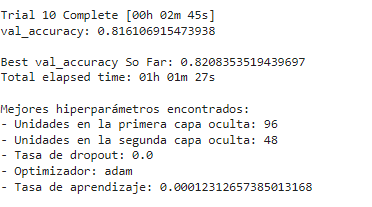

In [264]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Definir el optimizador
learning_rate = 0.0012312657385013168
optimizer = Adam(learning_rate=learning_rate)

# Crear el modelo
model = Sequential()

# Añadir capas al modelo con Dropout
model.add(Dense(96, input_dim=X_train_balanced.shape[1], activation='relu'))  # Capa oculta con 96 neuronas
model.add(Dropout(0.5))  # Dropout con tasa del 50%
model.add(Dense(48, activation='relu'))  # Capa oculta con 48 neuronas
model.add(Dropout(0.5))  # Dropout con tasa del 50%
model.add(Dense(1, activation='sigmoid'))  # Capa de salida con activación sigmoide para clasificación binaria

# Compilar el modelo
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(X_train_balanced, y_train_balanced, epochs=20, batch_size=32, validation_split=0.1)



Epoch 1/20


c:\Users\a.ruedal\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5847/5847 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7787 - loss: 0.4558 - val_accuracy: 0.7342 - val_loss: 0.5215
Epoch 2/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8241 - loss: 0.3817 - val_accuracy: 0.7271 - val_loss: 0.5333
Epoch 3/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8294 - loss: 0.3714 - val_accuracy: 0.7991 - val_loss: 0.4480
Epoch 4/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8359 - loss: 0.3622 - val_accuracy: 0.7965 - val_loss: 0.4245
Epoch 5/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8348 - loss: 0.3593 - val_accuracy: 0.8011 - val_loss: 0.4424
Epoch 6/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8354 - loss: 0.3585 - val_accuracy: 0.7917 - val_loss: 0.4549
Epoch 7/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8363 - loss: 0.3565 - val_accuracy: 0.8067 - val_loss: 0.4305
Epoch 8/20
5847/5847 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8371 - loss: 0.3547 - val_accu

## Encontrar Threshold óptimo

516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step


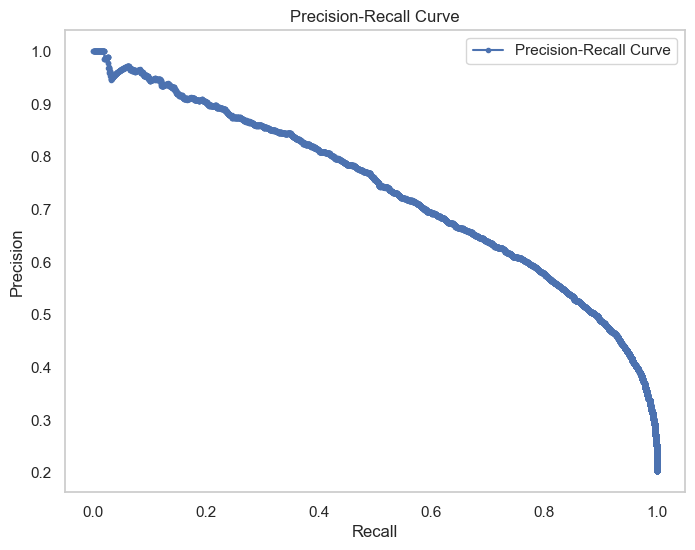

In [265]:
from sklearn.metrics import precision_recall_curve, f1_score
y_pred_prob = model.predict(X_test).ravel()

# Calcular precisión, recall y umbrales
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid()
plt.show()

In [266]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # Añadir un pequeño valor para evitar la división por cero

# Encontrar el umbral que maximiza el F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Max F1-score): {optimal_threshold}")
print(f"Maximum F1-score: {f1_scores[optimal_idx]:.4f}")

Optimal Threshold (Max F1-score): 0.49710577726364136
Maximum F1-score: 0.6749


In [267]:
from sklearn.metrics import confusion_matrix
# Realizar predicciones
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calcular el F1-score
f1 = f1_score(y_test, y_pred)
print(f'F1 Score: {f1}')
results["Neural N."] = f1
# Mostrar el informe de clasificación
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)



516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 654us/step
F1 Score: 0.6742857142857143
              precision    recall  f1-score   support

           0       0.93      0.88      0.90     13152
           1       0.61      0.76      0.67      3344

    accuracy                           0.85     16496
   macro avg       0.77      0.82      0.79     16496
weighted avg       0.87      0.85      0.86     16496



In [268]:
conf_matrix

array([[11508,  1644],
       [  807,  2537]], dtype=int64)

In [269]:
results

{'Neural N.': 0.6742857142857143}

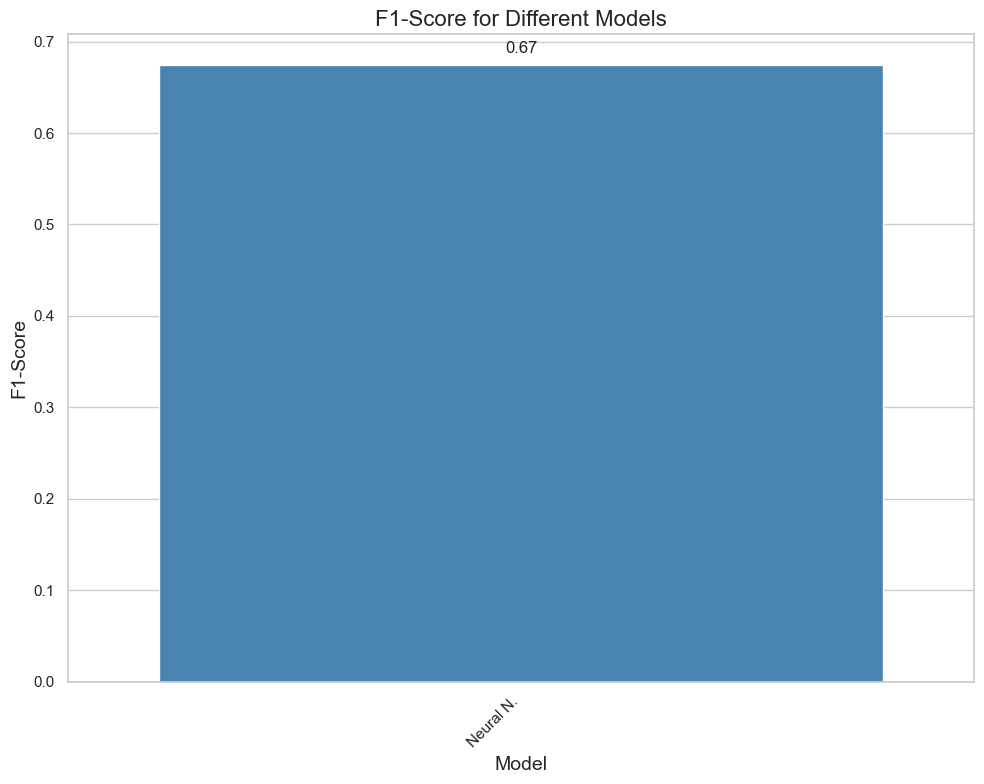

In [270]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear una figura con un tamaño adecuado
plt.figure(figsize=(10, 8))

# Usar seaborn para crear el gráfico de barras
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='Blues_d')

# Agregar etiquetas y título
plt.xlabel('Model', fontsize=14)
plt.ylabel('F1-Score', fontsize=14)
plt.title('F1-Score for Different Models', fontsize=16)

# Rotar las etiquetas del eje x
plt.xticks(rotation=45, ha='right')

# Mostrar los valores encima de las barras
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()



# Submission

In [271]:
X = test_hogares[["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c",'Dominio_BARRANQUILLA', 'Dominio_BUCARAMANGA',
       'Dominio_CALI', 'Dominio_CARTAGENA', 'Dominio_CUCUTA',
       'Dominio_FLORENCIA', 'Dominio_IBAGUE', 'Dominio_MANIZALES',
       'Dominio_MEDELLIN', 'Dominio_MONTERIA', 'Dominio_NEIVA',
       'Dominio_PASTO', 'Dominio_PEREIRA', 'Dominio_POPAYAN', 'Dominio_QUIBDO',
       'Dominio_RESTO URBANO', 'Dominio_RIOHACHA', 'Dominio_RURAL',
       'Dominio_SANTA MARTA', 'Dominio_SINCELEJO', 'Dominio_TUNJA',
       'Dominio_VALLEDUPAR', 'Dominio_VILLAVICENCIO',"Npersug", "Cotizan_p", "Nper", "Hasinación", "mean_escolaridad","mean_escolaridad_max", "Subsidios", "Ocupados", "P5090_2", "P5090_3","P5090_4" ,"P5090_5" ,"P5090_6", "P5130", "Subsidio_a", "Subsidio_e"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [272]:
#Submission xgb
y_pred = model.predict(X_scaled)

2068/2068 ━━━━━━━━━━━━━━━━━━━━ 1s 621us/step


In [273]:
y_pred

array([[0.17651485],
       [0.19205424],
       [0.00654617],
       ...,
       [0.48674986],
       [0.7886391 ],
       [0.62301016]], dtype=float32)

In [274]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten() > optimal_threshold).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)

In [174]:
#superlearners


# Super Learner

In [75]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Custom F1 Score Metric
def f1_score_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    def recall_m(y_true, y_pred):
        true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
        possible_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + tf.keras.backend.epsilon())
        return recall

    def precision_m(y_true, y_pred):
        true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
        predicted_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + tf.keras.backend.epsilon())
        return precision

    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + tf.keras.backend.epsilon()))

# Early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_f1_score_metric', patience=5, mode='max', verbose=1, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)

# Divide los datos en conjuntos de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X_train_balanced, y_train_balanced, test_size=0.2, random_state=42)

# Normaliza las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Arquitectura del modelo con regularización L2
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))  # Dropout rate
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

# Optimizador
optimizer = Adam(learning_rate=0.0012312657385013168, decay=0.01)

# Compilar el modelo
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[f1_score_metric])

# Entrenar el modelo
model.fit(X_train, y_train, 
          epochs=20, 
          batch_size=32, 
          validation_data=(X_val, y_val), 
          callbacks=[early_stopping, lr_schedule])

# Evaluar en el conjunto de validación y calcular la puntuación F1
y_val_pred = (model.predict(X_val) > 0.5).astype(int)
val_f1_score = f1_score(y_val, y_val_pred)

# Mostrar el F1 score
print(f'F1 score en el conjunto de validación: {val_f1_score}')


Epoch 1/20


c:\Users\a.ruedal\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\a.ruedal\AppData\Local\anaconda3\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


5197/5197 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - f1_score_metric: 0.7406 - loss: 0.4931 - val_f1_score_metric: 0.7893 - val_loss: 0.4014 - learning_rate: 0.0012
Epoch 2/20
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - f1_score_metric: 0.7868 - loss: 0.4110 - val_f1_score_metric: 0.7951 - val_loss: 0.3943 - learning_rate: 0.0012
Epoch 3/20
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - f1_score_metric: 0.7862 - loss: 0.4081 - val_f1_score_metric: 0.8008 - val_loss: 0.3942 - learning_rate: 0.0012
Epoch 4/20
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - f1_score_metric: 0.7906 - loss: 0.4058 - val_f1_score_metric: 0.7928 - val_loss: 0.3925 - learning_rate: 0.0012
Epoch 5/20
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score_metric: 0.7876 - loss: 0.4066 - val_f1_score_metric: 0.7920 - val_loss: 0.3929 - learning_rate: 0.0012
Epoch 6/20
5197/5197 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score_metric: 0.7872 - loss: 0.4072 - val_f1_score_metric: 0.7928 - val_loss: 0.3899 - learning_rate: 0.0012


516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


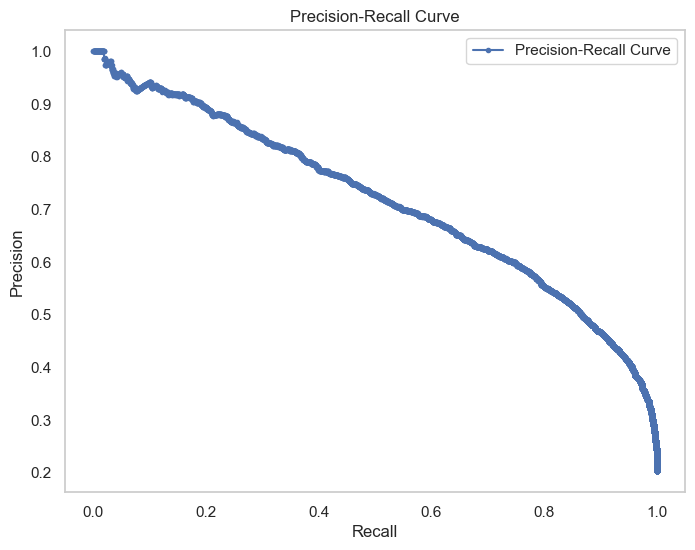

In [79]:
from sklearn.metrics import precision_recall_curve, f1_score
y_pred_prob = model.predict(X_test).ravel()

# Calcular precisión, recall y umbrales
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid()
plt.show()

In [80]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # Añadir un pequeño valor para evitar la división por cero

# Encontrar el umbral que maximiza el F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Max F1-score): {optimal_threshold}")
print(f"Maximum F1-score: {f1_scores[optimal_idx]:.4f}")

Optimal Threshold (Max F1-score): 0.753690242767334
Maximum F1-score: 0.6656


In [81]:
y_test_pred = (model.predict(X_test) > optimal_threshold).astype(int)

# Calcular el F1 score en el conjunto de test
test_f1_score = f1_score(y_test, y_test_pred)

# Mostrar el F1 score en el conjunto de test
print(f'F1 score en el conjunto de test: {test_f1_score}')

516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
F1 score en el conjunto de test: 0.6654250365837435


In [82]:
X = test_hogares[["P6210","P6020", "P6040", "P6050", "P6090", "Fex_c",'Dominio_BARRANQUILLA', 'Dominio_BUCARAMANGA',
       'Dominio_CALI', 'Dominio_CARTAGENA', 'Dominio_CUCUTA',
       'Dominio_FLORENCIA', 'Dominio_IBAGUE', 'Dominio_MANIZALES',
       'Dominio_MEDELLIN', 'Dominio_MONTERIA', 'Dominio_NEIVA',
       'Dominio_PASTO', 'Dominio_PEREIRA', 'Dominio_POPAYAN', 'Dominio_QUIBDO',
       'Dominio_RESTO URBANO', 'Dominio_RIOHACHA', 'Dominio_RURAL',
       'Dominio_SANTA MARTA', 'Dominio_SINCELEJO', 'Dominio_TUNJA',
       'Dominio_VALLEDUPAR', 'Dominio_VILLAVICENCIO',"Npersug", "Cotizan_p", "Nper", "Hasinación", "mean_escolaridad", "Subsidios", "Ocupados", "P5090_2", "P5090_3","P5090_4" ,"P5090_5" ,"P5090_6", "P5130", "Subsidio_a", "Subsidio_e"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [83]:
y_pred = model.predict(X_scaled)

2068/2068 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [84]:
y_pred

array([[0.22311509],
       [0.7027781 ],
       [0.03995853],
       ...,
       [0.7252859 ],
       [0.8601294 ],
       [0.8438198 ]], dtype=float32)

In [86]:
# Crear el DataFrame de submission
submission = pd.DataFrame({
    'id': test_hogares['id'],
    'pobre': (y_pred.flatten() > 0.5).astype(int)  # Convertir las probabilidades a 0 o 1
})

# Guardar el DataFrame en un archivo CSV
submission.to_csv('submission.csv', index=False)